In [1]:
######### EVENT-5 on 14-May-2024 #############

# Reading the Science data file (pixel fits file)

from astropy.io import fits
from astropy.time import Time, TimeDelta
import numpy as np
from functools import partial
from datetime import datetime, timedelta

# === Load FITS file ===
data_dir = '/home/jashhwanth/Desktop/solarflare/14_May_2024_New/' 
fits_filename = data_dir + 'solo_L1_stix-sci-xray-cpd_20240514T180146-20240514T180948_V02_2405141769-50415.fits'
hdulist = fits.open(fits_filename)

# Get the observation header (note: use primary header for DATE_OBS)
primary_header = hdulist[0].header
data_header = hdulist[2].header
print(data_header)


# Loop through each HDU
for i, hdu in enumerate(hdulist):
    print(f"\n===== HDU {i}: {hdu.name} =====")
    
    # Print header keys
    print("Header keys:")
    for key in list(hdu.header.keys())[:10]:  # Limit to first 10 keys for brevity
        print(f"  {key}: {hdu.header[key]}")
    
    # If it's a table HDU, print column names and formats
    if isinstance(hdu, fits.BinTableHDU):
        print("\nColumns:")
        for col in hdu.columns:
            print(f"  {col.name} ({col.format})")

# Close the file
# hdulist.close()

XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                39831 / length of dimension 1                          NAXIS2  =                  482 / length of dimension 2                          PCOUNT  =                    0 / number of group parameters                     GCOUNT  =                    1 / number of groups                               TFIELDS =                   11 / number of table fields                         TTYPE1  = 'time    '                                                            TFORM1  = 'J       '                                                            TUNIT1  = 'cs      '                                                            TSCAL1  =                    1                                                  TZERO1  =           2147483648          

In [2]:
start_time_str = primary_header['DATE-BEG']  # or check for 'DATE-BEG' if needed
start_time = Time(start_time_str, format='isot', scale='utc')

# === Read time arrays (in centiseconds) ===
time_sod = hdulist[2].data.field('time')       # Time since DATA_BEG in centiseconds
time_del = hdulist[2].data.field('timedel')   # Time bin width in centiseconds

# === Convert to seconds ===
time_offsets_sec = time_sod / 100.0
time_durations_sec = time_del / 100.0

# === Convert to absolute astropy Time objects ===
absolute_times = start_time + TimeDelta(time_offsets_sec, format='sec')

# === Optional: convert to datetime for compatibility with matplotlib, etc. ===
def convert_csec_to_datetime(csec_i, date_obs):
    if '.' in date_obs:
        date, frac = date_obs.split('.')
        frac = (frac + "000000")[:6]  # pad/truncate to 6-digit microseconds
        date_obs = f"{date}.{frac}"
        fmt = '%Y-%m-%dT%H:%M:%S.%f'
    else:
        fmt = '%Y-%m-%dT%H:%M:%S'

    try:
        dt = datetime.strptime(date_obs, fmt)
        return dt + timedelta(seconds=csec_i / 100.0)
    except Exception as e:
        print(f"Error parsing {date_obs} with csec_i={csec_i}: {e}")
        return None

map_func = partial(convert_csec_to_datetime, date_obs=start_time_str)
time_arr = np.asarray([map_func(csec) for csec in time_sod])

# === Read counts (time, 32 detectors, 12 pixels, 32 energy bins) ===
counts = hdulist[2].data.field('counts')

# === Read energy info ===
print("Energy column names:", hdulist[4].columns.names)
energy_labels = [f"{x}-{y} keV" for x, y in zip(hdulist[4].data['e_low'], hdulist[4].data['e_high'])]
energy_edges = [e_low + (e_high - e_low) for chn, e_low, e_high in hdulist[4].data]
energy_edges.insert(0, 0)
mean_energy = [(e_high + e_low) / 2 for chn, e_low, e_high in hdulist[4].data]

# === Print verification ===
print("Start Time:", start_time_str)
print("First astropy time:", absolute_times[0].iso)
print("First datetime object:", time_arr[0])
print("First bin duration (sec):", time_durations_sec[0])
print("Time points:", len(time_arr))


Energy column names: ['channel', 'e_low', 'e_high']
Start Time: 2024-05-14T18:01:46.594
First astropy time: 2024-05-14 18:01:47.094
First datetime object: 2024-05-14 18:01:47.094000
First bin duration (sec): 1.0
Time points: 482


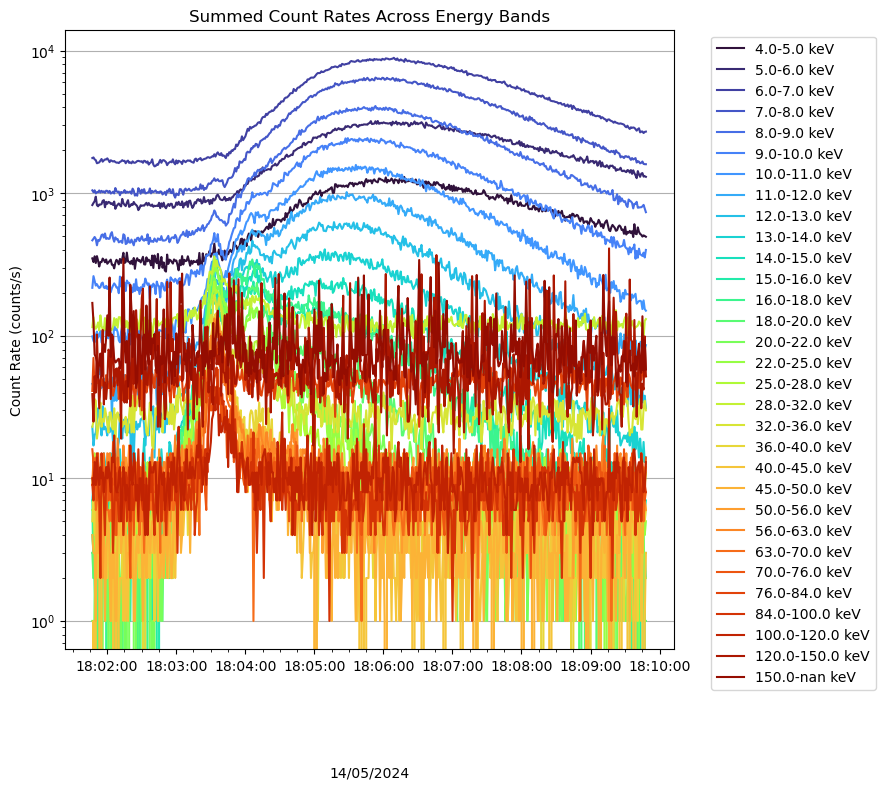

In [3]:
from astropy.io import fits
from astropy.time import Time, TimeDelta
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import dates as plt_dates
from functools import partial
from datetime import datetime , timezone
import datetime as dt
from matplotlib.ticker import FuncFormatter

# === Load FITS file ===
data_dir = '/home/jashhwanth/Desktop/solarflare/14_May_2024_New/' 
fits_filename = data_dir + 'solo_L1_stix-sci-xray-cpd_20240514T180146-20240514T180948_V02_2405141769-50415.fits'
hdulist = fits.open(fits_filename)

# === Get start time from header ===
data_header = hdulist[0].header
start_time_str = data_header['DATE-BEG']  # or check for 'DATE-BEG' if needed
start_time = Time(start_time_str, format='isot', scale='utc')

# === Read time arrays (in centiseconds) ===
time_sod = hdulist[2].data.field('time')       # Time since DATA_BEG in centiseconds
timedel = hdulist[2].data.field('timedel')    # Time bin width in centiseconds

# === Convert time from centiseconds to seconds ===
time_offsets_sec = time_sod / 100.0
time_durations_sec = timedel / 100.0  # Convert timedel to seconds

# === Absolute time arrays (astropy Time objects) ===
absolute_times = start_time + TimeDelta(time_offsets_sec, format='sec')

# === Convert to datetime (optional for matplotlib) ===
def convert_csec_to_datetime(csec_i, date_obs):
    if '.' in date_obs:
        date, frac = date_obs.split('.')
        frac = (frac + "000000")[:6]  # Ensure 6 digits for microseconds
        date_obs = f"{date}.{frac}"
        fmt = '%Y-%m-%dT%H:%M:%S.%f'
    else:
        fmt = '%Y-%m-%dT%H:%M:%S'
    try:
        dt = datetime.strptime(date_obs, fmt)
        return dt + timedelta(seconds=csec_i / 100.0)  # Convert centiseconds to seconds
    except Exception as e:
        print(f"Error parsing {date_obs} with csec_i={csec_i}: {e}")
        return None

map_func = partial(convert_csec_to_datetime, date_obs=start_time_str)
time_arr = np.asarray([map_func(csec) for csec in time_sod])

# === Read counts (time, 32 detectors, 12 pixels, 32 energy bins) ===
counts = hdulist[2].data.field('counts')  # Shape: (time, 32 detectors, 12 pixels, 32 energy bins)

# === Calculate count rate (counts/sec) ===
count_rate = counts / (timedel[:, None, None, None] / 100.0)  # Convert timedel from centiseconds to seconds

# === Sum over pixels and then detectors ===
summed_count_rates = count_rate.sum(axis=2).sum(axis=1)  # Shape: (time, 32 energy bins)

# === Produce energy labels ===
energy_labels = [str(x)+'-'+str(y)+' keV' for x, y in zip(hdulist[4].data['e_low'], hdulist[4].data['e_high'])]

# === Create the plot for summed count rates in all energy bands ===
fig = plt.figure(figsize=(9, 8), facecolor='w')
axes = fig.subplots(nrows=1, ncols=1)

# Get the 'turbo' colormap
cm = plt.get_cmap('turbo')

# Number of energy channels
num_colors = summed_count_rates.shape[1]

# Loop through all energy bins and plot the summed count rates
for chan in range(summed_count_rates.shape[1]):
    lines = axes.plot(time_arr, summed_count_rates[:, chan], label=energy_labels[chan])
    lines[0].set_color(cm(1. * chan / num_colors))

# === Customize the plot ===
axes.minorticks_on()
axes.yaxis.set_minor_locator(mticker.MultipleLocator(5))  # Minor ticks for y-axis
axes.set_yscale("log")  # Log scale for the y-axis
axes.set_ylabel('Count Rate (counts/s)')
axes.yaxis.grid(True, which='major')  # Major grid lines


# # Format x-axis with date format
# date_format = plt_dates.DateFormatter('%d/%m/%Y')
# axes.xaxis.set_major_formatter(date_format)

## Format x-axis with time in Hour:Minute:Second
time_format = plt_dates.DateFormatter('%H:%M:%S')  # Hour:Minute:Second format
axes.xaxis.set_major_formatter(time_format)

# Add the first date in the plot as text below the x-axis
axes.text(0.5, -0.2, datetime.date(time_arr[0]).strftime("%d/%m/%Y"), ha='center', va='center',
          transform=axes.transAxes)

# Title and legend
axes.set_title('Summed Count Rates Across Energy Bands')
axes.legend(bbox_to_anchor=(1.05, 1))

# Show the plot
plt.tight_layout()
plt.show()

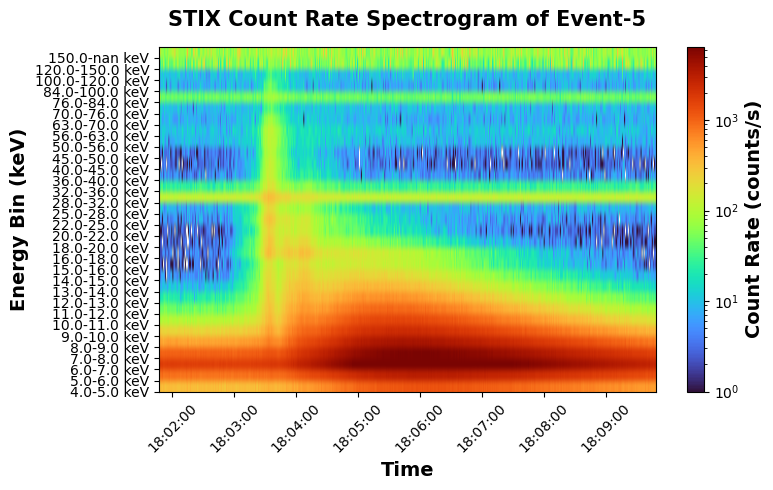

In [9]:
# Count Rate Spectrogram

from matplotlib.colors import LogNorm
import matplotlib.dates as mdates

# === Transpose the data for imshow ===
spectrogram_data = summed_count_rates.T  # Shape: (energy_bins, time)

# === Create figure and axis ===
fig, ax = plt.subplots(figsize=(8, 5), facecolor='w')

# === Convert datetime array to matplotlib date numbers ===
time_nums = mdates.date2num(time_arr)

# === Plot the spectrogram ===
im = ax.imshow(spectrogram_data, 
               aspect='auto', 
               origin='lower',
               extent=[time_nums[0], time_nums[-1], 0, len(energy_labels)],
               cmap='turbo',
               norm=LogNorm(vmin=np.percentile(spectrogram_data, 1), 
                            vmax=np.percentile(spectrogram_data, 99)))  # Use log scale

# === Y-axis energy bin labels ===
ax.set_yticks(np.arange(len(energy_labels)))
ax.set_yticklabels(energy_labels)

# === X-axis time formatting ===
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

# === Labels and title ===
ax.set_xlabel("Time", fontsize=14, fontweight='bold')
ax.set_ylabel("Energy Bin (keV)", fontsize=14, fontweight='bold')
ax.set_title("STIX Count Rate Spectrogram of Event-5", fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45)

# === Colorbar ===
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Count Rate (counts/s)", fontsize=14, fontweight='bold')

plt.tight_layout()

# Save it as an image
plt.savefig("E5 spectrogram.jpg")

plt.show()

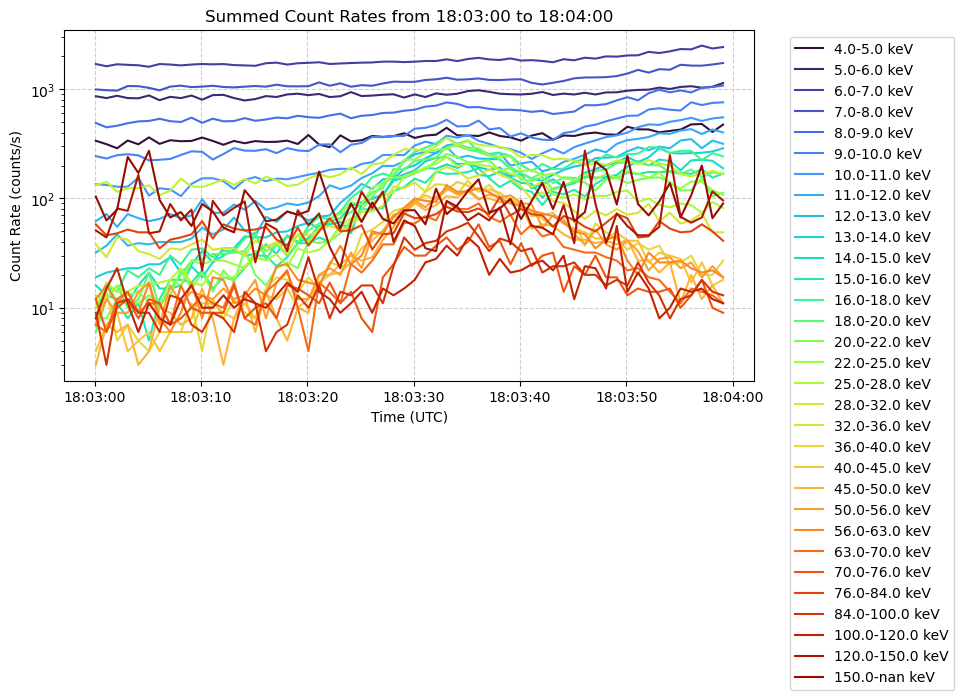

In [5]:
# === Define the desired time range ===
range_start = datetime.strptime('18:03:00', '%H:%M:%S').time()
range_end = datetime.strptime('18:04:00', '%H:%M:%S').time()

# === Filter indices for the time range ===
selected_indices = [i for i, t in enumerate(time_arr)
                    if range_start <= t.time() <= range_end]

# === Subset time and count rates ===
time_subset = time_arr[selected_indices]
count_subset = summed_count_rates[selected_indices]

# === Plot time vs count rate for each energy bin ===
fig, ax = plt.subplots(figsize=(10, 6), facecolor='w')

num_colors = count_subset.shape[1]
cm = plt.get_cmap('turbo')

for chan in range(num_colors):
    ax.plot(time_subset, count_subset[:, chan], label=energy_labels[chan],
            color=cm(1. * chan / num_colors))

ax.set_yscale("log")
ax.set_ylabel('Count Rate (counts/s)')
ax.set_xlabel('Time (UTC)')
ax.set_title(f'Summed Count Rates from {range_start} to {range_end}')
ax.xaxis.set_major_formatter(plt_dates.DateFormatter('%H:%M:%S'))
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
ax.grid(True, which='major', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

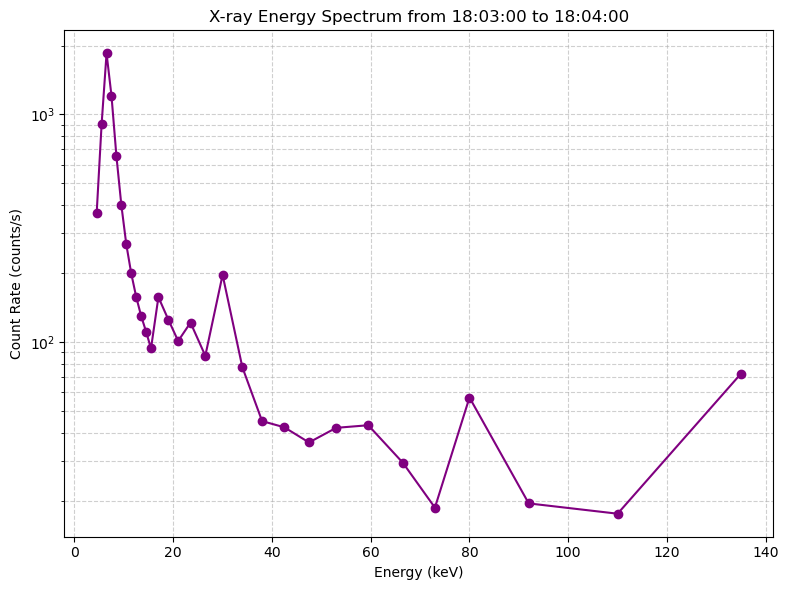

In [6]:
# Plotting of Energy Spectrogram for Specfic time interval

import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# === Define start and end time (in datetime format) ===
start_time_str = '18:03:00'
end_time_str = '18:04:00'

# === Convert strings to datetime.time ===
start_time_obj = datetime.strptime(start_time_str, "%H:%M:%S").time()
end_time_obj = datetime.strptime(end_time_str, "%H:%M:%S").time()

# === Filter indices within the time range ===
selected_indices = [i for i, t in enumerate(time_arr) 
                    if start_time_obj <= t.time() <= end_time_obj]

# === Average spectrum over the selected time range ===
spectrum = summed_count_rates[selected_indices].mean(axis=0)

# === Energy bin centers for plotting ===
e_low = hdulist[4].data['e_low']
e_high = hdulist[4].data['e_high']
e_mid = (e_low + e_high) / 2

# === Plot the spectrum ===
plt.figure(figsize=(8, 6))
plt.plot(e_mid, spectrum, marker='o', linestyle='-', color='purple')

plt.xlabel('Energy (keV)')
plt.ylabel('Count Rate (counts/s)')
plt.yscale('log')  # Optional
plt.title(f'X-ray Energy Spectrum from {start_time_str} to {end_time_str}')
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

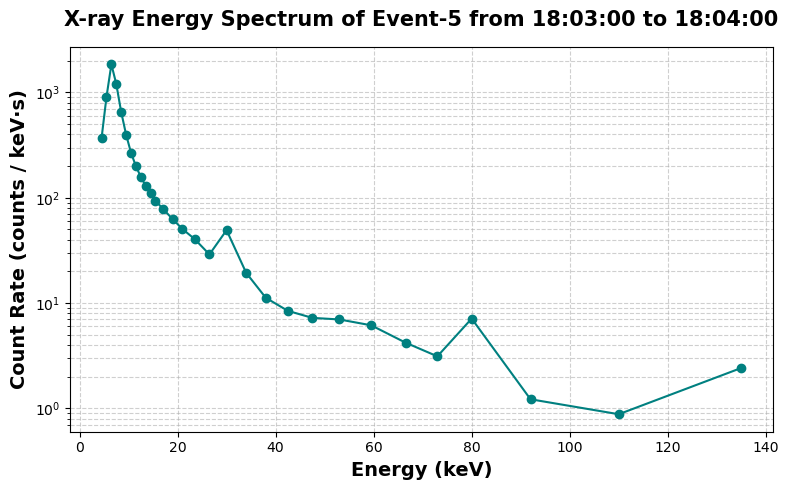

In [10]:
# Plotting of Energy Spectrogram for Specfic time interval (count/(KeV s))

import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# === Define start and end time (in datetime format) ===
start_time_str = '18:03:00'
end_time_str = '18:04:00'

# === Convert strings to datetime.time ===
start_time_obj = datetime.strptime(start_time_str, "%H:%M:%S").time()
end_time_obj = datetime.strptime(end_time_str, "%H:%M:%S").time()

# === Filter indices within the time range ===
selected_indices = [i for i, t in enumerate(time_arr) 
                    if start_time_obj <= t.time() <= end_time_obj]

# === Average spectrum over the selected time range ===
spectrum_counts_per_s = summed_count_rates[selected_indices].mean(axis=0)

# === Energy bin edges ===
e_low = hdulist[4].data['e_low']
e_high = hdulist[4].data['e_high']
e_mid = (e_low + e_high) / 2
e_width = e_high - e_low  # Bin width in keV

# === Convert counts/s to counts/(keV·s) ===
spectrum_per_keV = spectrum_counts_per_s / e_width

# === Plot the spectrum ===
plt.figure(figsize=(8, 5))
plt.plot(e_mid, spectrum_per_keV, marker='o', linestyle='-', color='teal')

plt.xlabel('Energy (keV)', fontsize=14, fontweight='bold')
plt.ylabel(r'Count Rate (counts / keV·s)', fontsize=14, fontweight='bold')
plt.yscale('log')  # Optional, for better contrast
plt.title(f'X-ray Energy Spectrum of Event-5 from {start_time_str} to {end_time_str}', fontsize=15, fontweight='bold', pad=15)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()

# Save it as an image
plt.savefig("E5 spectrum.jpg")

plt.show()
